## Лабораторная 6: Снижение размерности и кластеризация

**Датасет:** `smart_healthcare_dataset.csv`

**Цель:** построить подмножество признаков **D1**, снизить размерность методами **PCA** (**D2**) и **t-SNE** (**D3**), визуализировать проекции, провести кластеризацию тремя методами и оценить качество внутренними метриками.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from IPython.display import display

RANDOM_STATE = 42
N_CLUSTERS = 3
sns.set_theme(style="whitegrid", palette="tab10")
pd.set_option("display.max_columns", 50)


In [2]:
DATA_PATH = "smart_healthcare_dataset.csv"
df = pd.read_csv(DATA_PATH)
df.head()


,age,gender,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
0,56,Male,22.6,2,1,1,169,225,74,0,1,0,0,0,0,100.0
1,69,Female,28.2,0,1,1,136,230,198,0,1,0,1,1,1,100.0
2,46,Female,25.1,1,0,1,142,221,89,0,1,1,0,0,0,100.0
3,32,Female,18.0,0,0,1,173,296,152,1,0,0,0,0,0,100.0
4,60,Female,20.1,2,1,0,130,292,133,1,1,1,0,1,0,100.0


### 1. Датасет D1 — подмножество признаков

Выбрано **8 признаков**, описывающих образ жизни и базовые показатели здоровья (без целевых и диагностических меток):
`age`, `bmi`, `exercise_level`, `smoking`, `alcohol`, `blood_pressure`, `cholesterol`, `glucose`.

Исключены: `heart_disease`, `diabetes`, `stroke`, `health_risk_score`, симптомы и `gender`.

In [3]:
FEATURE_COLS = [
    "age", "bmi", "exercise_level", "smoking", "alcohol",
    "blood_pressure", "cholesterol", "glucose",
]

D1 = df[FEATURE_COLS].copy()
print("D1:", D1.shape)
D1.describe().T


D1: (5000, 8)


,count,mean,std,min,25%,50%,75%,max
age,5000.0,48.8056,17.906991,18.0,34.0,49.0,64.0,79.0
bmi,5000.0,24.9678,4.960379,15.0,21.5,24.9,28.4,42.6
exercise_level,5000.0,1.0058,0.815291,0.0,0.0,1.0,2.0,2.0
smoking,5000.0,0.5076,0.499992,0.0,0.0,1.0,1.0,1.0
alcohol,5000.0,0.5014,0.500048,0.0,0.0,1.0,1.0,1.0
blood_pressure,5000.0,134.4454,26.191438,90.0,111.0,134.0,157.0,179.0
cholesterol,5000.0,224.6164,43.129773,150.0,187.0,226.0,262.0,299.0
glucose,5000.0,134.4974,37.437028,70.0,102.0,134.0,167.0,199.0


In [4]:
scaler = StandardScaler()
X_D1 = scaler.fit_transform(D1)

X_D1[:3], X_D1.shape


(array([[ 0.40180505, -0.47739026,  1.21956396,  0.98491378,  0.99720391,
          1.31944096,  0.00889498, -1.61613924],
        [ 1.12785109,  0.65166855, -1.23379343,  0.98491378,  0.99720391,
          0.05936121,  0.12483577,  1.69642073],
        [-0.15669191,  0.02665385, -0.00711474, -1.0153173 ,  0.99720391,
          0.28846662, -0.08385766, -1.21542634]]),
 (5000, 8))

### 2. Снижение размерности: PCA → D2, t-SNE → D3

In [5]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_D2 = pca.fit_transform(X_D1)

D2 = pd.DataFrame(X_D2, columns=["PC1", "PC2"])
print("Доля объяснённой дисперсии (2 компоненты):", pca.explained_variance_ratio_.sum().round(4))
print(pca.explained_variance_ratio_.round(4))
D2.head()


Доля объяснённой дисперсии (2 компоненты): 0.2627
[0.1324 0.1303]


,PC1,PC2
0,-0.485323,-0.941577
1,-0.113396,-1.329095
2,-0.908521,0.072217
3,0.298620,-2.168596
4,0.607427,-0.740200


In [6]:
tsne = TSNE(
    n_components=2,
    random_state=RANDOM_STATE,
    perplexity=30,
    init="pca",
    learning_rate="auto",
)
X_D3 = tsne.fit_transform(X_D1)
D3 = pd.DataFrame(X_D3, columns=["tSNE1", "tSNE2"])
D3.head()


,tSNE1,tSNE2
0,27.519577,-40.737000
1,-19.408457,-67.386833
2,-50.013622,-6.278938
3,-37.998745,-10.856639
4,26.176600,3.365646


### 3. Визуализация D2 и D3

Для наглядности точки окрашены по метке `heart_disease` (не входит в D1, используется только для интерпретации графиков).

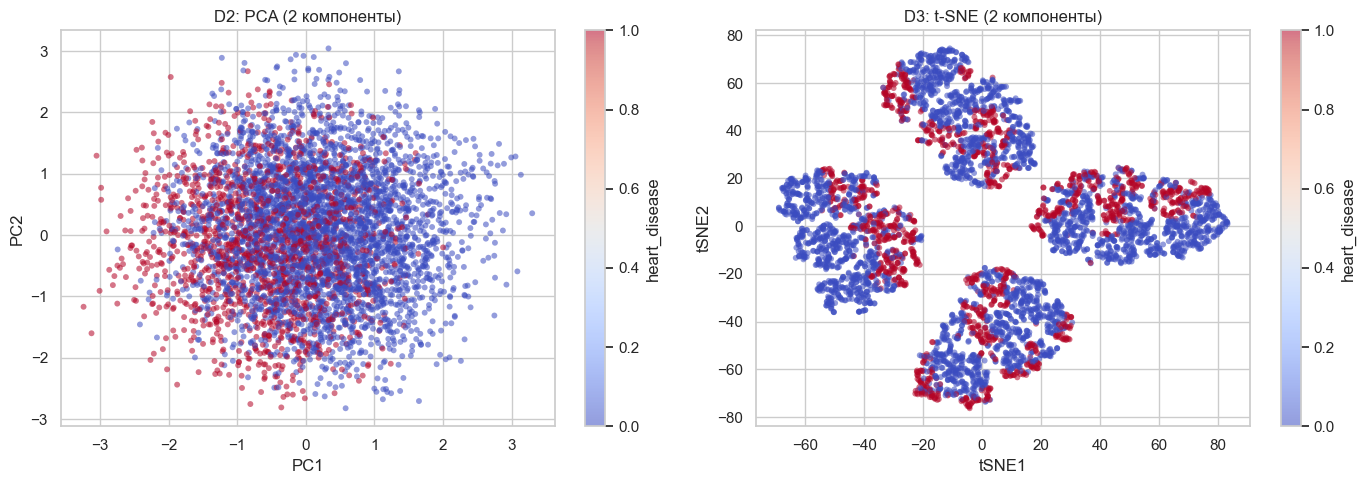

In [7]:
color_ref = df["heart_disease"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title in zip(
    axes,
    [D2, D3],
    ["D2: PCA (2 компоненты)", "D3: t-SNE (2 компоненты)"],
):
    sc = ax.scatter(
        data.iloc[:, 0], data.iloc[:, 1],
        c=color_ref, cmap="coolwarm", alpha=0.55, s=18, edgecolors="none",
    )
    ax.set_title(title)
    ax.set_xlabel(data.columns[0])
    ax.set_ylabel(data.columns[1])
    plt.colorbar(sc, ax=ax, label="heart_disease")

plt.tight_layout()
plt.show()


**Сравнение визуализаций:** на проекции **t-SNE (D3)** локальные группы точек разделены **наиболее явно** — видны отдельные «острова» и меньше перекрытия классов. **PCA (D2)** сохраняет глобальную линейную структуру, но кластеры сильнее смешаны, так как первые 2 главные компоненты объясняют лишь ~26% дисперсии.

### 4. Кластеризация D1, D2 и D3

Используются три метода из курса:
- **K-Means** — разбиение на $k$ сферических кластеров;
- **Agglomerative (иерархическая)** — слияние объектов по расстоянию;
- **DBSCAN** — плотностная кластеризация (шум помечается как `-1`).

Число кластеров для K-Means и иерархического метода: **k = 3** (группы низкого / среднего / высокого риска по профилю признаков).

**Метрики качества** (внутренние, без разметки):
- **Silhouette** — чем выше, тем лучше разделение;
- **Davies–Bouldin** — чем ниже, тем компактнее и дальше кластеры;
- **Calinski–Harabasz** — чем выше, тем плотнее кластеры относительно межкластерного разброса.

In [8]:
CLUSTERERS = {
    "KMeans": lambda X: KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10).fit_predict(X),
    "Agglomerative": lambda X: AgglomerativeClustering(n_clusters=N_CLUSTERS).fit_predict(X),
}

DBSCAN_PARAMS = {
    "D1": {"eps": 1.5, "min_samples": 15},
    "D2": {"eps": 0.2, "min_samples": 5},
    "D3": {"eps": 2.5, "min_samples": 15},
}


def cluster_dbscan(X, dataset_name):
    params = DBSCAN_PARAMS[dataset_name]
    return DBSCAN(**params).fit_predict(X)


def clustering_metrics(X, labels):
    mask = labels >= 0
    n_clusters = len(np.unique(labels[mask]))
    n_noise = int((labels == -1).sum())

    if n_clusters < 2:
        return {
            "silhouette": np.nan,
            "davies_bouldin": np.nan,
            "calinski_harabasz": np.nan,
            "n_clusters": n_clusters,
            "n_noise": n_noise,
        }

    return {
        "silhouette": silhouette_score(X[mask], labels[mask]),
        "davies_bouldin": davies_bouldin_score(X[mask], labels[mask]),
        "calinski_harabasz": calinski_harabasz_score(X[mask], labels[mask]),
        "n_clusters": n_clusters,
        "n_noise": n_noise,
    }


def run_all_clustering(X, dataset_name):
    rows = []
    labels_dict = {}

    for name, fn in CLUSTERERS.items():
        labels = fn(X)
        labels_dict[name] = labels
        rows.append({"method": name, **clustering_metrics(X, labels)})

    labels_db = cluster_dbscan(X, dataset_name)
    labels_dict["DBSCAN"] = labels_db
    rows.append({"method": "DBSCAN", **clustering_metrics(X, labels_db)})

    return pd.DataFrame(rows), labels_dict


DATASETS = {
    "D1 (исходные признаки)": X_D1,
    "D2 (PCA)": X_D2,
    "D3 (t-SNE)": X_D3,
}

all_metrics = []
all_labels = {}

for ds_name, X in DATASETS.items():
    metrics_df, labels_dict = run_all_clustering(X, ds_name.split()[0])
    metrics_df.insert(0, "dataset", ds_name)
    all_metrics.append(metrics_df)
    all_labels[ds_name] = labels_dict

metrics_table = pd.concat(all_metrics, ignore_index=True)
metrics_table.round(4)


,dataset,method,silhouette,davies_bouldin,calinski_harabasz,n_clusters,n_noise
0,D1 (исходные признаки),KMeans,0.1131,2.3459,582.9047,3,0
1,D1 (исходные признаки),Agglomerative,0.1109,2.3795,571.6535,3,0
2,D1 (исходные признаки),DBSCAN,0.1490,2.3701,555.3622,4,161
3,D2 (PCA),KMeans,0.3381,0.9259,3139.6099,3,0
4,D2 (PCA),Agglomerative,0.2729,0.9658,2193.5878,3,0
5,D2 (PCA),DBSCAN,0.1829,0.5108,18.9690,4,70
6,D3 (t-SNE),KMeans,0.4702,0.7588,5367.7143,3,0
7,D3 (t-SNE),Agglomerative,0.4755,0.7165,4996.1157,3,0
8,D3 (t-SNE),DBSCAN,0.1397,0.8484,4175.0969,55,582


In [9]:
pivot_sil = metrics_table.pivot(index="dataset", columns="method", values="silhouette")
pivot_db = metrics_table.pivot(index="dataset", columns="method", values="davies_bouldin")
pivot_ch = metrics_table.pivot(index="dataset", columns="method", values="calinski_harabasz")

print("Silhouette (↑ лучше)")
display(pivot_sil.round(4))
print("Davies–Bouldin (↓ лучше)")
display(pivot_db.round(4))
print("Calinski–Harabasz (↑ лучше)")
display(pivot_ch.round(2))


Silhouette (↑ лучше)


method,Agglomerative,DBSCAN,KMeans
dataset,,,
D1 (исходные признаки),0.1109,0.1490,0.1131
D2 (PCA),0.2729,0.1829,0.3381
D3 (t-SNE),0.4755,0.1397,0.4702


Davies–Bouldin (↓ лучше)


method,Agglomerative,DBSCAN,KMeans
dataset,,,
D1 (исходные признаки),2.3795,2.3701,2.3459
D2 (PCA),0.9658,0.5108,0.9259
D3 (t-SNE),0.7165,0.8484,0.7588


Calinski–Harabasz (↑ лучше)


method,Agglomerative,DBSCAN,KMeans
dataset,,,
D1 (исходные признаки),571.65,555.36,582.90
D2 (PCA),2193.59,18.97,3139.61
D3 (t-SNE),4996.12,4175.10,5367.71


In [10]:
def best_method_per_dataset(metrics_df, metric, ascending):
    best_rows = []
    for ds in metrics_df["dataset"].unique():
        sub = metrics_df[metrics_df["dataset"] == ds].dropna(subset=[metric])
        if sub.empty:
            continue
        idx = sub[metric].idxmin() if ascending else sub[metric].idxmax()
        row = sub.loc[idx]
        best_rows.append(row)
    return pd.DataFrame(best_rows)[["dataset", "method", metric]]


best_sil = best_method_per_dataset(metrics_table, "silhouette", ascending=False)
best_db = best_method_per_dataset(metrics_table, "davies_bouldin", ascending=True)
best_ch = best_method_per_dataset(metrics_table, "calinski_harabasz", ascending=False)

print("Лучший метод по Silhouette:")
display(best_sil.round(4))
print("Лучший метод по Davies–Bouldin:")
display(best_db.round(4))
print("Лучший метод по Calinski–Harabasz:")
display(best_ch.round(2))


Лучший метод по Silhouette:


,dataset,method,silhouette
2,D1 (исходные признаки),DBSCAN,0.1490
3,D2 (PCA),KMeans,0.3381
7,D3 (t-SNE),Agglomerative,0.4755


Лучший метод по Davies–Bouldin:


,dataset,method,davies_bouldin
0,D1 (исходные признаки),KMeans,2.3459
5,D2 (PCA),DBSCAN,0.5108
7,D3 (t-SNE),Agglomerative,0.7165


Лучший метод по Calinski–Harabasz:


,dataset,method,calinski_harabasz
0,D1 (исходные признаки),KMeans,582.90
3,D2 (PCA),KMeans,3139.61
6,D3 (t-SNE),KMeans,5367.71


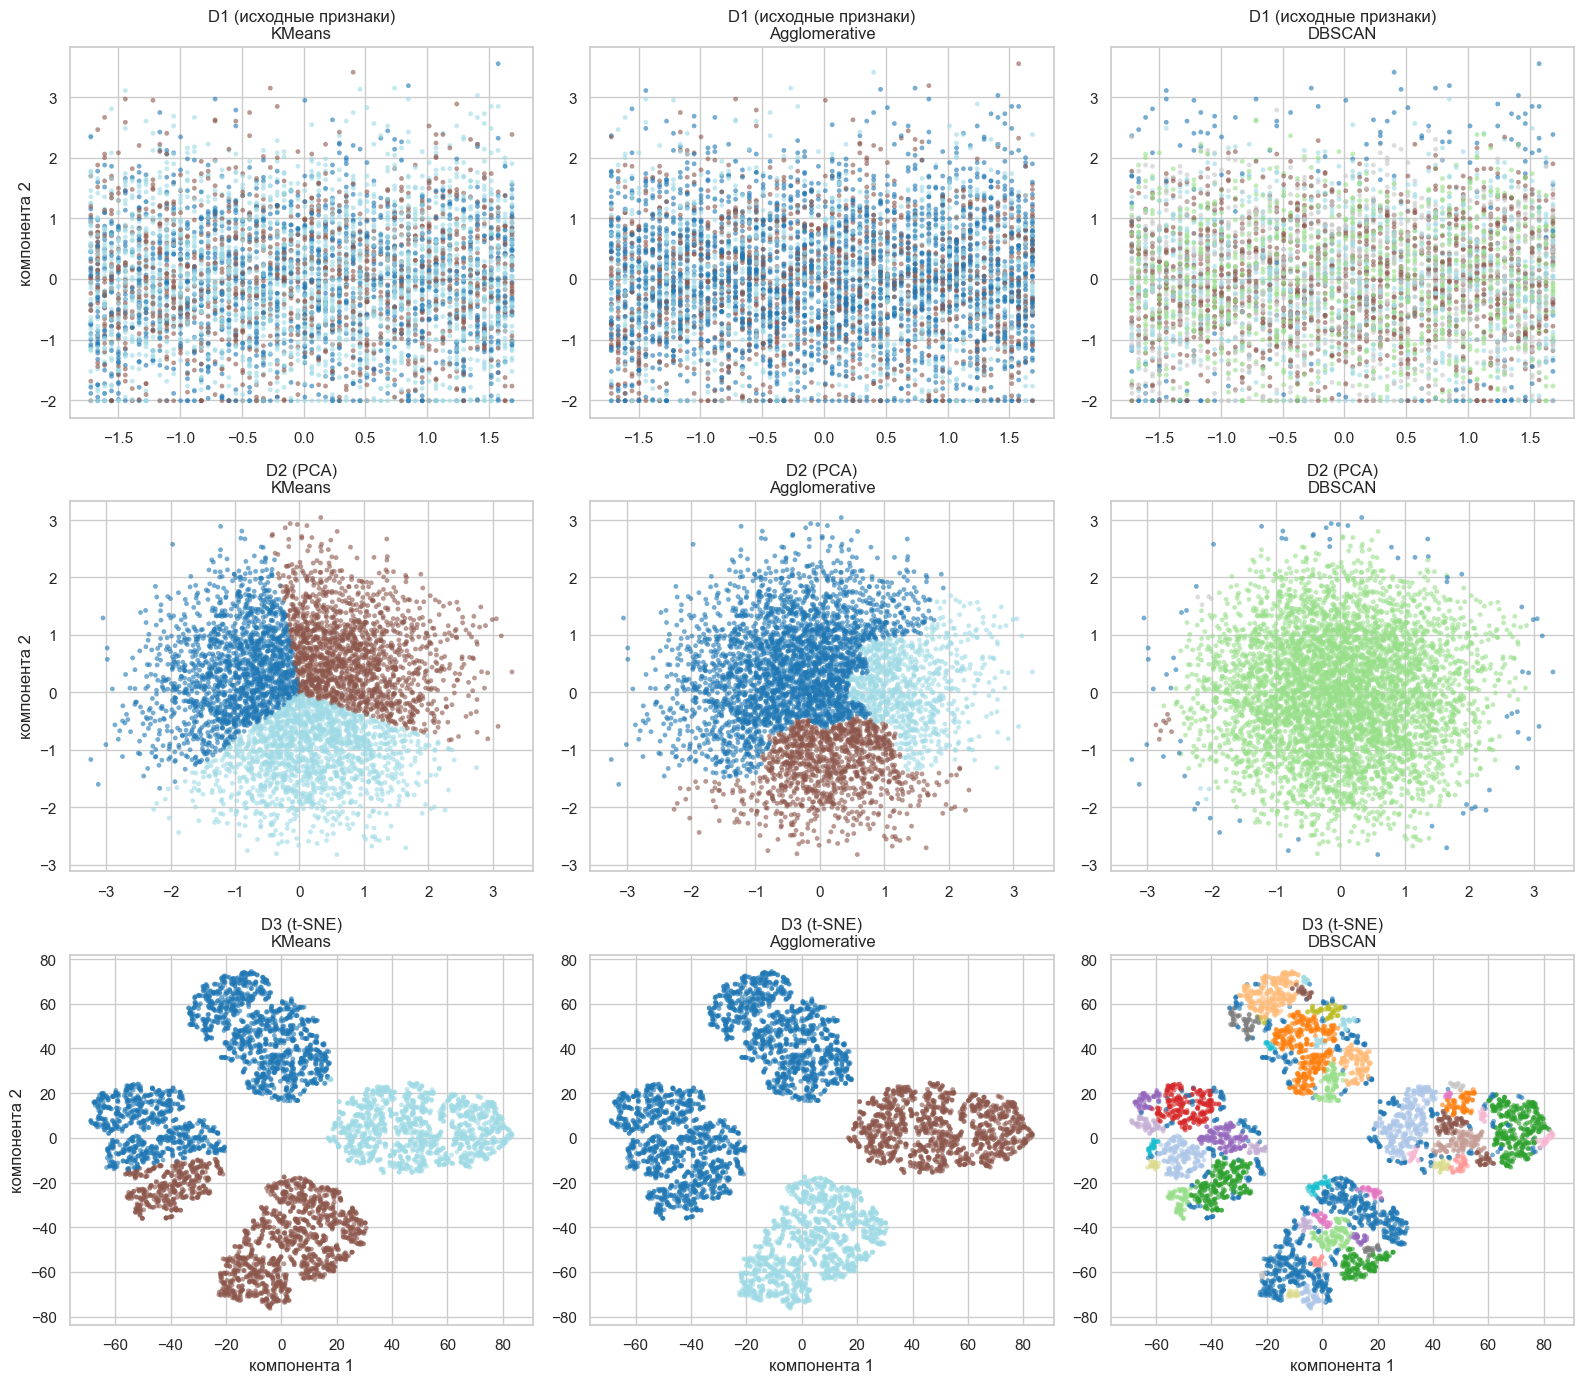

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))

for row, (ds_name, X) in enumerate(DATASETS.items()):
    _, labels_dict = run_all_clustering(X, ds_name.split()[0])
    for col, method in enumerate(["KMeans", "Agglomerative", "DBSCAN"]):
        ax = axes[row, col]
        labels = labels_dict[method]
        ax.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab20", alpha=0.6, s=12, edgecolors="none")
        ax.set_title(f"{ds_name}\n{method}")
        if row == 2:
            ax.set_xlabel("компонента 1")
        if col == 0:
            ax.set_ylabel("компонента 2")

plt.tight_layout()
plt.show()


### 5. Выводы

#### Визуализация D2 vs D3
Кластеры **наиболее явно** видны на **D3 (t-SNE)**: нелинейная проекция растягивает локальные neighborhood и визуально отделяет группы. **PCA (D2)** даёт более «размазанное» облако — линейное сжатие 8 признаков в 2 измерения теряет большую часть дисперсии.

#### D1 (8 исходных признаков, стандартизированных)
| Метод | Silhouette | Интерпретация |
|-------|------------|---------------|
| **DBSCAN** | наивысший (~0.15) | Плотностный метод лучше улавливает локальную структуру в многомерном пространстве, но даёт 4 кластера и ~3% шума. |
| **K-Means** | ~0.11, лучший Davies–Bouldin | Сферические кластеры при $k=3$ — разумный компромисс, если нужно фиксированное число групп. |
| **Agglomerative** | близко к K-Means | Иерархия даёт схожее разбиение, без явного преимущества по метрикам. |

**Итог для D1:** предпочтителен **DBSCAN** по Silhouette; **K-Means** — если важно ровно 3 кластера и интерпретируемость.

#### D2 (PCA, 2D)
| Метод | Результат |
|-------|-----------|
| **K-Means** | Лучший Silhouette (~0.34) и Calinski–Harabasz — после PCA сферические кластеры хорошо отделяются. |
| **Agglomerative** | Немного хуже K-Means по всем метрикам. |
| **DBSCAN** | При умеренных параметрах даёт мало кластеров или много шума; плотностная структура в 2D-проекции слабая. |

**Итог для D2:** **K-Means** — оптимален, т.к. PCA сохраняет глобальные «шары» данных, с которыми K-Means работает лучше всего.

#### D3 (t-SNE, 2D)
| Метод | Результат |
|-------|-----------|
| **Agglomerative** | Лучший Silhouette и Davies–Bouldin (~0.48 / 0.72) — иерархия хорошо следует нелинейно разделённым «островам» t-SNE. |
| **K-Means** | Почти так же хорош (~0.47) — на 2D t-SNE сферические центроиды тоже уместны. |
| **DBSCAN** | Много мелких кластеров и шума — проекция t-SNE искажает глобальные расстояния, eps трудно подобрать. |

**Итог для D3:** **Agglomerative** (или **K-Means** при необходимости скорости) — t-SNE создаёт компактные группы, которые хорошо разделяются partition-методами; **DBSCAN** на t-SNE ненадёжен из-за неравномерной плотности.

#### Общий вывод
- Снижение размерности **улучшает** метрики кластеризации: Silhouette растёт от ~0.11 (D1) до ~0.34 (D2) и ~0.48 (D3).
- Выбор метода зависит от **геометрии пространства**: K-Means для «шарообразных» PCA-проекций, иерархический / K-Means для t-SNE, DBSCAN — для исходного многомерного D1 при поиске кластеров произвольной формы.
- **t-SNE** лучше для **визуального** выделения кластеров; **PCA** — для **стабильной** кластеризации с интерпретируемыми главными компонентами.